In [702]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from solvers import *
import torch
import torch.nn as nn

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [703]:
def tenor_to_years(tenor: str) -> float:
    """
    Parse tenors like '1D','2W','3M','6M','1Y','2Y','10Y' into year fractions.
    Uses simple conversions: 365d, 52w, 12m.
    """
    t = str(tenor).strip().upper()
    m = re.fullmatch(r"(\d+)\s*([DWMY])", t)
    if not m:
        raise ValueError(f"Could not parse tenor: {tenor}")
    n = int(m.group(1))
    u = m.group(2)
    if u == "D":
        return n / 365.0
    if u == "W":
        return n / 52.0
    if u == "M":
        return n / 12.0
    if u == "Y":
        return float(n)
    raise ValueError(f"Unknown tenor unit: {u}")

def load_swap_curve_from_excel(path, row="last"):
    """
    Expects tenors in column headers and one (or multiple) rows of swap rates.
    - If multiple rows exist, choose last by default (row="last"), else row=0 for first.
    - Tries to drop non-tenor columns gracefully.
    Returns: T_years (np array), s_market (np array as decimals, e.g. 0.025)
    """
    df = pd.read_excel(path, index_col='date').dropna()
    # choose row
    if row == "last":
        series = df.iloc[-1]
    elif isinstance(row, int):
        series = df.iloc[row]
    else:
        raise ValueError("row must be 'last' or an integer row index")

    Ts = [tenor_to_years(t) for t in df.columns]
    rs = series.values.tolist()

    if len(Ts) < 3:
        raise RuntimeError("Found too few tenor columns. Check the Excel headers.")

    Ts = np.array(Ts, dtype=float)
    rs = np.array(rs, dtype=float)/100

    # sort by maturity
    idx = np.argsort(Ts)
    Ts, rs = Ts[idx], rs[idx]

    return Ts, rs

# --- set your file path here ---
excel_path = "swaps.xlsx"   # <-- change
T_mkt, s_mkt = load_swap_curve_from_excel(excel_path, row="last")


In [704]:
s_mkt

array([0.0475    , 0.0472    , 0.04621494, 0.04550192, 0.04619703,
       0.04700865, 0.04792173, 0.04878409, 0.05279167])

In [705]:
def make_s_and_sprime(T, s, poly_deg=5):
    """
    Returns callables s_fun(T) and sp_fun(T) using:
    - SciPy CubicSpline if available
    - else polynomial fit fallback
    """
    T = np.asarray(T, float)
    s = np.asarray(s, float)

    try:
        from scipy.interpolate import CubicSpline
        cs = CubicSpline(T, s, bc_type="natural", extrapolate=True)
        def s_fun(x):
            x = np.asarray(x, float)
            return cs(x)
        def sp_fun(x):
            x = np.asarray(x, float)
            return cs(x, 1)
        backend = "scipy_cubicspline"
        return s_fun, sp_fun, backend
    except Exception as e:
        # polynomial fit fallback (least squares)
        deg = min(poly_deg, len(T) - 1)
        coeff = np.polyfit(T, s, deg=deg)
        dcoeff = np.polyder(coeff)
        def s_fun(x):
            x = np.asarray(x, float)
            return np.polyval(coeff, x)
        def sp_fun(x):
            x = np.asarray(x, float)
            return np.polyval(dcoeff, x)
        backend = f"polyfit_deg_{deg}"
        return s_fun, sp_fun, backend

s_fun, sp_fun, interp_backend = make_s_and_sprime(T_mkt, s_mkt)
interp_backend

'scipy_cubicspline'

In [706]:
class PINN(nn.Module):
    def __init__(self, hidden=64, depth=4):
        super().__init__()
        layers = []
        in_dim = 1
        out_dim = 2  # [A_raw, g_raw]
        dims = [in_dim] + [hidden]*depth + [out_dim]
        for i in range(len(dims)-2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, T):
        # T shape: (N,1)
        out = self.net(T)
        A = out[:, :1]                        # unconstrained
        g = out[:, 1:2]
        P = torch.exp(-g)                     # in (0,1]
        return A, P

model = PINN(hidden=20, depth=2).to(device)
sum(p.numel() for p in model.parameters())


502

In [707]:
# Domain
T_max = float(T_mkt.max())
T0 = 0.0

# Torch wrappers for s(T), s'(T)
def torch_s(T_tensor):
    # T_tensor shape (N,1)
    x = T_tensor.detach().cpu().numpy().reshape(-1)
    y = s_fun(x)
    return torch.tensor(y, dtype=torch.float64, device=device).reshape(-1, 1)

def torch_sp(T_tensor):
    x = T_tensor.detach().cpu().numpy().reshape(-1)
    y = sp_fun(x)
    return torch.tensor(y, dtype=torch.float64, device=device).reshape(-1, 1)

# Market tensors
T_mkt_t = torch.tensor(T_mkt, dtype=torch.float64, device=device).reshape(-1, 1)
s_mkt_t = torch.tensor(s_mkt, dtype=torch.float64, device=device).reshape(-1, 1)

def loss_fn(model, n_colloc=2048):
    # Collocation points in (0, T_max)
    T_c = torch.rand(n_colloc, 1, device=device, dtype=torch.float64) * T_max
    T_c.requires_grad_(True)

    A_c, P_c = model(T_c)

    # dA/dT
    dA = torch.autograd.grad(A_c, T_c, grad_outputs=torch.ones_like(A_c), create_graph=True)[0]
    # dP/dT
    dP = torch.autograd.grad(P_c, T_c, grad_outputs=torch.ones_like(P_c), create_graph=True)[0]

    s_c = torch_s(T_c)
    sp_c = torch_sp(T_c)

    r1 = dA - P_c
    r2 = dP + sp_c * A_c + s_c * P_c

    L_phys = r1.pow(2).mean() + r2.pow(2).mean()

    # Boundary conditions at T=0
    T_b = torch.zeros(1, 1, device=device, dtype=torch.float64, requires_grad=True)
    A_b, P_b = model(T_b)
    L_bc = (A_b).pow(2).mean() + (P_b - 1.0).pow(2).mean()

    # Market par condition at quoted maturities: s(Tk)*A(Tk) = 1 - P(Tk)
    A_k, P_k = model(T_mkt_t)
    L_mkt = (s_mkt_t * A_k - (1.0 - P_k)).pow(2).mean()

    # Optional monotonicity penalty: want P'(T) <= 0
    # penalize positive derivative
    L_mono = torch.relu(dP).pow(2).mean()

    L = L_phys + L_bc + L_mkt + L_mono
    return L, {"L_phys": L_phys.item(), "L_bc": L_bc.item(), "L_mkt": L_mkt.item(), "L_mono": L_mono.item()}

# # --- Adam pretrain ---
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

history = []
steps = 10_000

for step in range(steps):
    opt.zero_grad()
    L, parts = loss_fn(model, n_colloc=2048)
    L.backward()
    opt.step()

    if step % 200 == 0 or step == steps-1:
        parts["L"] = float(L.item())
        parts["step"] = step
        history.append(parts)
        print(parts)

# --- Optional: L-BFGS refinement (often improves PINN residuals) ---

# lbfgs = BFGS(model.parameters(), max_iter=10_000, tolerance_change=1e-20, tolerance_grad=1e-20)

# def closure(*args, **kwargs):
#     lbfgs.zero_grad()
#     L, _ = loss_fn(model, n_colloc=5_000)
#     L.backward()
#     return L

# final_L = lbfgs.step(closure)
# print("LBFGS done, final loss:", float(final_L))


{'L_phys': 0.6594148030929549, 'L_bc': 0.20514649356103928, 'L_mkt': 0.029874549741676415, 'L_mono': 1.2176144515479156e-05, 'L': 0.894448022540186, 'step': 0}
{'L_phys': 0.06359799525660126, 'L_bc': 0.00024468287652955274, 'L_mkt': 0.08173843036758026, 'L_mono': 0.0, 'L': 0.14558110850071107, 'step': 200}
{'L_phys': 0.015895284575467048, 'L_bc': 4.935695656274479e-05, 'L_mkt': 0.025225923508387798, 'L_mono': 0.0, 'L': 0.04117056504041759, 'step': 400}
{'L_phys': 0.005523782922762028, 'L_bc': 6.855982507792804e-06, 'L_mkt': 0.008778955707092723, 'L_mono': 0.0, 'L': 0.014309594612362544, 'step': 600}
{'L_phys': 0.0023620798714763043, 'L_bc': 2.589023997345082e-06, 'L_mkt': 0.0027089659347642576, 'L_mono': 0.0, 'L': 0.005073634830237907, 'step': 800}
{'L_phys': 0.0009725323607981985, 'L_bc': 6.42480867657956e-07, 'L_mkt': 0.0006593291931217463, 'L_mono': 0.0, 'L': 0.0016325040347876028, 'step': 1000}
{'L_phys': 0.00040020890851825145, 'L_bc': 2.463303108794651e-07, 'L_mkt': 0.00014108686

In [708]:
model.eval()

# Dense grid
T_grid = np.linspace(0.0, T_max, 600)
Tg = torch.tensor(T_grid, dtype=torch.float64, device=device).reshape(-1, 1)
Tg.requires_grad_(True)

A_g, P_g = model(Tg)  # A(T), discount factor P(T)

# instantaneous forward f(T) = -d/dT log P(T)
logP = torch.log(P_g)
dlogP = torch.autograd.grad(logP, Tg, grad_outputs=torch.ones_like(logP), create_graph=False)[0]
f_g = (-dlogP).detach().cpu().numpy().reshape(-1)

A_np = A_g.detach().cpu().numpy().reshape(-1)
P_np = P_g.detach().cpu().numpy().reshape(-1)

# implied continuous par swap rate: s_hat(T) = (1 - P(T)) / A(T), for T>0
s_imp = np.full_like(T_grid, np.nan, dtype=float)
mask = T_grid > 1e-6
s_imp[mask] = (1.0 - P_np[mask]) / A_np[mask]

# market curve for comparison
s_smooth = s_fun(T_grid)

# also compute implied swap at market tenors (from model)
with torch.no_grad():
    A_k, P_k = model(T_mkt_t)
s_imp_mkt = ((1.0 - P_k) / A_k).detach().cpu().numpy().reshape(-1)


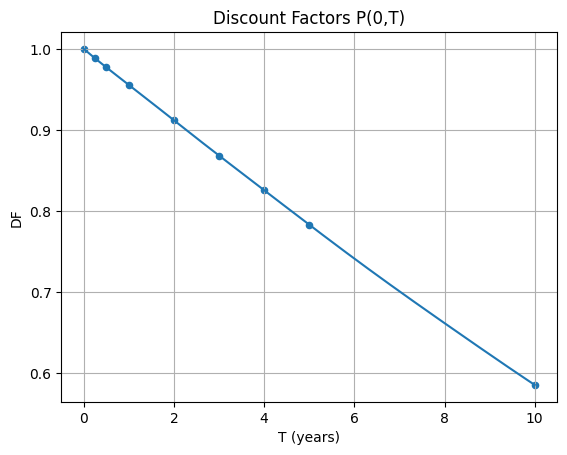

In [709]:
plt.figure()
plt.plot(T_grid, P_np)
plt.scatter(T_mkt, np.interp(T_mkt, T_grid, P_np), s=20)
plt.title("Discount Factors P(0,T)")
plt.xlabel("T (years)")
plt.ylabel("DF")
plt.grid(True)
plt.show()


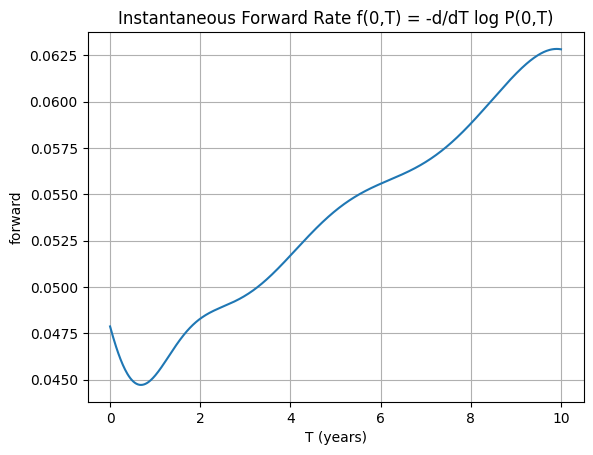

In [710]:
plt.figure()
plt.plot(T_grid, f_g)
plt.title("Instantaneous Forward Rate f(0,T) = -d/dT log P(0,T)")
plt.xlabel("T (years)")
plt.ylabel("forward")
plt.grid(True)
plt.show()


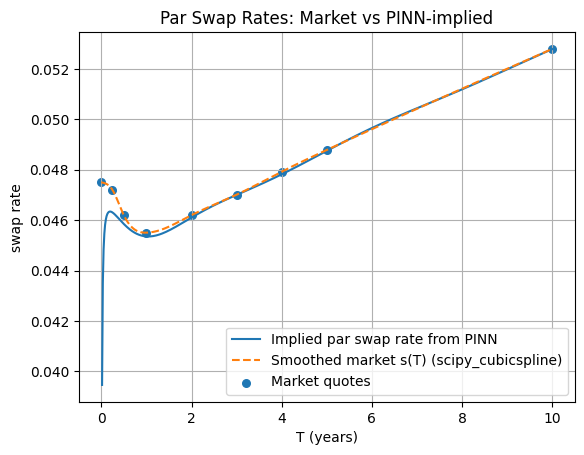

In [711]:
plt.figure()
plt.plot(T_grid, s_imp, label="Implied par swap rate from PINN")
plt.plot(T_grid, s_smooth, "--", label=f"Smoothed market s(T) ({interp_backend})")
plt.scatter(T_mkt, s_mkt, label="Market quotes", s=30)
plt.title("Par Swap Rates: Market vs PINN-implied")
plt.xlabel("T (years)")
plt.ylabel("swap rate")
plt.grid(True)
plt.legend()
plt.show()


In [712]:
diag = pd.DataFrame({
    "Tenor_Years": T_mkt,
    "Market_s": s_mkt,
    "PINN_implied_s": s_imp_mkt,
    "AbsErr": np.abs(s_imp_mkt - s_mkt),
})
diag


,Tenor_Years,Market_s,PINN_implied_s,AbsErr
0,0.002740,0.047500,0.002900,0.044600
1,0.246575,0.047200,0.046304,0.000896
2,0.493151,0.046215,0.045857,0.000358
3,1.000000,0.045502,0.045354,0.000148
4,2.000000,0.046197,0.046102,0.000096
5,3.000000,0.047009,0.047001,0.000008
6,4.000000,0.047922,0.047817,0.000105
7,5.000000,0.048784,0.048748,0.000036
8,10.000000,0.052792,0.052783,0.000008
